# RecSys Learning-to-Rank with CatBoost

В этом ноутбуке собран полный оффлайн-пайплайн ранжирования для рекомендательной системы: от подготовки implicit feedback и генерации кандидатов до обучения моделей и сравнения ranking-метрик.


In [ ]:
import os
import math
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import scipy.sparse as sp
from sklearn.feature_extraction import FeatureHasher
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, CatBoostRanker, Pool

RATINGS_PATH = "data/rating.csv"   
MOVIES_PATH  = "data/movie.csv"    

SEED = 42
rng = np.random.default_rng(SEED)

POS_THRESHOLD = 4.0
MIN_POS_PER_USER = 3

NEG_PER_POS_TRAIN = 2
NEG_PER_USER_TEST = 49

MAX_POS_PER_USER_TRAIN = 30
MAX_USERS_TRAIN = 12000
MAX_USERS_EVAL  = 3000
  

HASH_DIMS = 2**18
TOPK_LIST = [5, 10, 20]


c:\Users\CHIKOBAVA-PC\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Загрузка данных

На этом шаге загружается `rating.csv`, при наличии подключается `movie.csv`, а также формируется бинарный признак релевантности: оценки выше заданного порога считаются положительными взаимодействиями.


In [2]:
ratings = pd.read_csv(RATINGS_PATH)

if np.issubdtype(ratings["timestamp"].dtype, np.number):
    ratings["ts"] = pd.to_datetime(ratings["timestamp"], unit="s")
else:
    ratings["ts"] = pd.to_datetime(ratings["timestamp"])

ratings = ratings.rename(columns={"userId": "userId", "movieId": "movieId"})
ratings = ratings[["userId", "movieId", "rating", "ts"]].copy()
ratings["is_pos"] = (ratings["rating"] >= POS_THRESHOLD).astype(np.int8)

movies = None
if os.path.exists(MOVIES_PATH):
    movies = pd.read_csv(MOVIES_PATH)[["movieId", "genres"]].copy()
    genre_ohe = movies["genres"].fillna("(no genres listed)").str.get_dummies(sep="|")
    movies = pd.concat([movies[["movieId"]], genre_ohe], axis=1)

ratings.head()


,userId,movieId,rating,ts,is_pos
0,1,2,3.5,2005-04-02 23:53:47,0
1,1,29,3.5,2005-04-02 23:31:16,0
2,1,32,3.5,2005-04-02 23:33:39,0
3,1,47,3.5,2005-04-02 23:32:07,0
4,1,50,3.5,2005-04-02 23:29:40,0


## 2. Подготовка implicit feedback и временное разбиение

Для каждого пользователя оставляем только тех, у кого достаточно положительных взаимодействий. Последний релевантный фильм уходит в тест, остальные используются для обучения.


In [3]:
pos = ratings[ratings["is_pos"] == 1].sort_values(["userId", "ts"]).copy()
pos_cnt = pos.groupby("userId")["movieId"].size().rename("pos_cnt").reset_index()
pos = pos.merge(pos_cnt, on="userId", how="left")
pos = pos[pos["pos_cnt"] >= MIN_POS_PER_USER].copy()

pos = pos.sort_values(["userId", "ts"])
pos["rn"] = pos.groupby("userId").cumcount()
pos["rn_rev"] = pos["pos_cnt"] - 1 - pos["rn"]

test_pos = pos[pos["rn_rev"] == 0][["userId", "movieId", "ts"]].copy()
train_pos = pos[pos["rn_rev"] >= 1][["userId", "movieId", "ts"]].copy()

users = test_pos["userId"].unique()
if MAX_USERS_TRAIN is not None and len(users) > MAX_USERS_TRAIN:
    users = rng.choice(users, size=MAX_USERS_TRAIN, replace=False)
    test_pos = test_pos[test_pos["userId"].isin(users)].copy()
    train_pos = train_pos[train_pos["userId"].isin(users)].copy()

print("users:", test_pos["userId"].nunique(), "train_pos:", len(train_pos), "test_pos:", len(test_pos))


users: 12000 train_pos: 867489 test_pos: 12000


## 3. Статистики пользователей и фильмов

Здесь считаются агрегаты, которые потом идут в признаки: активность пользователя, средняя оценка, популярность фильма, число релевантных взаимодействий и жанровые признаки.


In [4]:
cutoff = test_pos.rename(columns={"ts": "cutoff_ts"})[["userId", "cutoff_ts"]].copy()

rt = ratings.merge(cutoff, on="userId", how="inner")
rt = rt[rt["ts"] < rt["cutoff_ts"]].copy()

user_stats = rt.groupby("userId").agg(
    user_cnt=("movieId", "size"),
    user_mean_rating=("rating", "mean"),
).reset_index()

item_stats = rt.groupby("movieId").agg(
    item_cnt=("userId", "size"),
    item_mean_rating=("rating", "mean"),
).reset_index()

item_pos_cnt = rt[rt["is_pos"] == 1].groupby("movieId").size().rename("item_pos_cnt").reset_index()
item_stats = item_stats.merge(item_pos_cnt, on="movieId", how="left")
item_stats["item_pos_cnt"] = item_stats["item_pos_cnt"].fillna(0).astype(int)

if movies is not None:
    item_stats = item_stats.merge(movies, on="movieId", how="left")

global_mean = float(ratings["rating"].mean())

print("rt rows:", len(rt), "unique items:", item_stats["movieId"].nunique())


rt rows: 1705614 unique items: 18065


## 4. Negative sampling и подготовка признаков

Определяем набор всех фильмов, функцию семплирования нерелевантных объектов и функцию `add_features`, которая объединяет пары user-item с пользовательскими, товарными и временными признаками.


In [5]:
all_items = np.array(ratings["movieId"].unique(), dtype=np.int64)

train_pos_by_user = train_pos.groupby("userId")["movieId"].apply(lambda x: set(x.values)).to_dict()

def sample_negs(exclude_set, n):
    res = []
    seen = set()
    while len(res) < n:
        m = int(rng.choice(all_items))
        if m in exclude_set:
            continue
        if m in seen:
            continue
        seen.add(m)
        res.append(m)
    return res

def add_features(df):
    out = df.merge(user_stats, on="userId", how="left")
    out = out.merge(item_stats, on="movieId", how="left")

    out["user_cnt"] = out["user_cnt"].fillna(0)
    out["user_mean_rating"] = out["user_mean_rating"].fillna(global_mean)
    out["item_cnt"] = out["item_cnt"].fillna(0)
    out["item_mean_rating"] = out["item_mean_rating"].fillna(global_mean)
    out["item_pos_cnt"] = out["item_pos_cnt"].fillna(0)

    out["hour"] = out["ts"].dt.hour.astype(int)
    out["dow"] = out["ts"].dt.dayofweek.astype(int)
    out["month"] = out["ts"].dt.month.astype(int)

    out = out.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out



## 5. Формирование обучающей выборки

Для каждого положительного взаимодействия добавляется несколько отрицательных примеров. Так получаются пары для обучения pointwise и ranking-моделей.


In [6]:
rows = []
for u, g in tqdm(train_pos.groupby("userId"), total=train_pos["userId"].nunique()):
    g = g.sort_values("ts")
    pos_items = g["movieId"].tolist()
    if len(pos_items) > MAX_POS_PER_USER_TRAIN:
        pos_items = pos_items[-MAX_POS_PER_USER_TRAIN:]

    user_pos_set = train_pos_by_user.get(u, set())

    ts_list = g["ts"].tolist()
    if len(ts_list) > MAX_POS_PER_USER_TRAIN:
        ts_list = ts_list[-MAX_POS_PER_USER_TRAIN:]

    for m, t in zip(pos_items, ts_list):
        rows.append((u, int(m), 1, t))
        negs = sample_negs(user_pos_set, NEG_PER_POS_TRAIN)
        for nm in negs:
            rows.append((u, int(nm), 0, t))

train_pairs = pd.DataFrame(rows, columns=["userId", "movieId", "label", "ts"])
train_pairs = add_features(train_pairs)

print(train_pairs.shape)
train_pairs.head()


100%|██████████| 12000/12000 [00:10<00:00, 1145.35it/s]


(872904, 32)


,userId,movieId,label,ts,user_cnt,user_mean_rating,item_cnt,item_mean_rating,item_pos_cnt,(no genres listed),...,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,hour,dow,month
0,1,5816,1,2005-04-02 23:48:40,168.0,3.755952,1262.0,3.616878,642.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,5,4
1,1,7170,0,2005-04-02 23:48:40,168.0,3.755952,3.0,1.666667,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,5,4
2,1,51617,0,2005-04-02 23:48:40,168.0,3.755952,0.0,3.525529,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,5,4
3,1,4896,1,2005-04-02 23:48:51,168.0,3.755952,1461.0,3.652977,777.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,5,4
4,1,46967,0,2005-04-02 23:48:51,168.0,3.755952,63.0,3.444444,29.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,23,5,4


## 6. Формирование тестовых кандидатов

В тесте для каждого пользователя создается набор кандидатов: один релевантный фильм и набор случайных нерелевантных фильмов. Именно по этим наборам затем считается качество ранжирования.


In [7]:
eval_users = test_pos["userId"].unique()
if MAX_USERS_EVAL is not None and len(eval_users) > MAX_USERS_EVAL:
    eval_users = rng.choice(eval_users, size=MAX_USERS_EVAL, replace=False)

test_pos_sub = test_pos[test_pos["userId"].isin(eval_users)].copy()

rows = []
for _, r in tqdm(test_pos_sub.iterrows(), total=len(test_pos_sub)):
    u = int(r["userId"])
    true_m = int(r["movieId"])
    t = r["ts"]

    exclude = set(train_pos_by_user.get(u, set()))
    exclude.add(true_m)

    negs = sample_negs(exclude, NEG_PER_USER_TEST)

    rows.append((u, true_m, 1, t))
    for nm in negs:
        rows.append((u, int(nm), 0, t))

test_cand = pd.DataFrame(rows, columns=["userId", "movieId", "label", "ts"])
test_cand = add_features(test_cand)

print(test_cand.shape)
test_cand.head()


100%|██████████| 3000/3000 [00:01<00:00, 1956.13it/s]


(150000, 32)


,userId,movieId,label,ts,user_cnt,user_mean_rating,item_cnt,item_mean_rating,item_pos_cnt,(no genres listed),...,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,hour,dow,month
0,41,2969,1,2000-02-27 23:31:30,58,4.103448,62.0,3.596774,36.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,23,6,2
1,41,110771,0,2000-02-27 23:31:30,58,4.103448,11.0,2.909091,2.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,23,6,2
2,41,3057,0,2000-02-27 23:31:30,58,4.103448,3.0,3.666667,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,6,2
3,41,124713,0,2000-02-27 23:31:30,58,4.103448,0.0,3.525529,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,6,2
4,41,93467,0,2000-02-27 23:31:30,58,4.103448,0.0,3.525529,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,6,2


## 7. Метрики ранжирования

Функции ниже считают `Recall@K`, `Precision@K`, `NDCG@K` и `MRR@K`. Это основной инструмент для сравнения моделей в оффлайн-оценке.


In [8]:
def eval_ranking(df_scored, k=10):
    ndcgs, hits, mrrs = [], [], []

    for u, g in df_scored.groupby("userId"):
        g = g.sort_values("score", ascending=False).reset_index(drop=True)

        topk = g.head(k)
        hit = int(topk["label"].max() > 0)
        hits.append(hit)

        pos_idx = g.index[g["label"] == 1]
        rank = int(pos_idx[0] + 1) if len(pos_idx) else None

        if rank is None or rank > k:
            ndcgs.append(0.0)
            mrrs.append(0.0)
        else:
            ndcgs.append(1.0 / math.log2(rank + 1))
            mrrs.append(1.0 / rank)

    recall = float(np.mean(hits))     # при 1 позитиве на юзера это HitRate@k
    precision = float(np.mean(hits) / k)
    return {
        f"Recall@{k}": recall,
        f"Precision@{k}": precision,
        f"NDCG@{k}": float(np.mean(ndcgs)),
        f"MRR@{k}": float(np.mean(mrrs)),
    }

def eval_all_ks(df_scored, ks):
    out = {}
    for k in ks:
        out.update(eval_ranking(df_scored, k=k))
    return out


## 8. Бейзлайны

Сначала считаются простые ориентиры: ранжирование по популярности и по средней оценке фильма. Они нужны как точка отсчета перед обучением более сильных моделей.


In [9]:
pop_map = item_stats.set_index("movieId")["item_pos_cnt"].to_dict()
mean_map = item_stats.set_index("movieId")["item_mean_rating"].to_dict()

baseline_pop = test_cand[["userId", "label"]].copy()
baseline_pop["score"] = test_cand["movieId"].map(lambda x: pop_map.get(int(x), 0))

baseline_mean = test_cand[["userId", "label"]].copy()
baseline_mean["score"] = test_cand["movieId"].map(lambda x: mean_map.get(int(x), global_mean))

res = []
res.append({"model": "baseline_popularity", **eval_all_ks(baseline_pop.assign(userId=test_cand["userId"]), TOPK_LIST)})
res.append({"model": "baseline_item_mean", **eval_all_ks(baseline_mean.assign(userId=test_cand["userId"]), TOPK_LIST)})

pd.DataFrame(res)


,model,Recall@5,Precision@5,NDCG@5,MRR@5,Recall@10,Precision@10,NDCG@10,MRR@10,Recall@20,Precision@20,NDCG@20,MRR@20
0,baseline_popularity,0.855,0.1710,0.672660,0.611883,0.952,0.0952,0.704324,0.625127,0.992000,0.049600,0.714590,0.628024
1,baseline_item_mean,0.318,0.0636,0.178284,0.132711,0.584,0.0584,0.264284,0.168187,0.672667,0.033633,0.287876,0.175285


## 9. Подготовка признаков для моделей

Здесь собираются числовые признаки и hashed-признаки user/item, после чего строятся матрицы `X_train` и `X_test` для линейной модели и классического градиентного бустинга.


In [10]:
num_cols = ["user_cnt", "user_mean_rating", "item_cnt", "item_mean_rating", "item_pos_cnt", "hour", "dow", "month"]
genre_cols = []
if movies is not None:
    genre_cols = [c for c in item_stats.columns if c not in ["movieId", "item_cnt", "item_mean_rating", "item_pos_cnt"]]
    # genre cols уже в test/train через merge
    for c in genre_cols:
        if c not in train_pairs.columns:
            genre_cols = []
            break

num_cols_full = num_cols + genre_cols

hasher = FeatureHasher(n_features=HASH_DIMS, input_type="string")

def hashed_ids(df):
    tokens = (("u:" + df["userId"].astype(str)) + " " + ("i:" + df["movieId"].astype(str))).tolist()
    tokens = [t.split(" ") for t in tokens]
    return hasher.transform(tokens)

def build_X(df):
    Xh = hashed_ids(df)
    Xn = sp.csr_matrix(df[num_cols_full].to_numpy(dtype=np.float32))
    return sp.hstack([Xh, Xn], format="csr")

X_train = build_X(train_pairs)
y_train = train_pairs["label"].astype(int).to_numpy()

X_test = build_X(test_cand)
y_test = test_cand["label"].astype(int).to_numpy()

print(X_train.shape, X_test.shape)


(872904, 262172) (150000, 262172)


## 10. Линейная модель и числовой бустинг

Сравниваются два базовых ML-подхода: `SGDClassifier` на hashed user/item признаках и `HistGradientBoostingClassifier` на числовых признаках.


In [11]:
sgd = SGDClassifier(loss="log_loss", alpha=1e-5, random_state=SEED, max_iter=20, tol=1e-3)
sgd.fit(X_train, y_train)

sgd_score = sgd.decision_function(X_test)
sgd_scored = test_cand[["userId", "label"]].copy()
sgd_scored["score"] = sgd_score

res.append({"model": "SGD_logreg_hash", **eval_all_ks(sgd_scored, TOPK_LIST)})
print("SGD AUC (test candidates):", roc_auc_score(y_test, sgd_score))

hgb = HistGradientBoostingClassifier(random_state=SEED, max_depth=6, learning_rate=0.1)
hgb.fit(train_pairs[num_cols_full].to_numpy(), train_pairs["label"].astype(int).to_numpy())

hgb_proba = hgb.predict_proba(test_cand[num_cols_full].to_numpy())[:, 1]
hgb_scored = test_cand[["userId", "label"]].copy()
hgb_scored["score"] = hgb_proba

res.append({"model": "HistGB_numeric", **eval_all_ks(hgb_scored, TOPK_LIST)})

pd.DataFrame(res).sort_values(f"NDCG@{TOPK_LIST[1]}", ascending=False)


c:\Users\CHIKOBAVA-PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGD AUC (test candidates): 0.9253783401360545


,model,Recall@5,Precision@5,NDCG@5,MRR@5,Recall@10,Precision@10,NDCG@10,MRR@10,Recall@20,Precision@20,NDCG@20,MRR@20
3,HistGB_numeric,0.859667,0.171933,0.675608,0.614328,0.952333,0.095233,0.705967,0.627086,0.991333,0.049567,0.715997,0.629928
0,baseline_popularity,0.855000,0.171000,0.672660,0.611883,0.952000,0.095200,0.704324,0.625127,0.992000,0.049600,0.714590,0.628024
2,SGD_logreg_hash,0.847667,0.169533,0.667831,0.607822,0.928333,0.092833,0.694140,0.618812,0.974333,0.048717,0.705907,0.622115
1,baseline_item_mean,0.318000,0.063600,0.178284,0.132711,0.584000,0.058400,0.264284,0.168187,0.672667,0.033633,0.287876,0.175285


## 11. CatBoostClassifier

На этом шаге обучается pointwise-модель `CatBoostClassifier`, которая предсказывает вероятность релевантности для пары user-item.


In [12]:
train_cb = train_pairs.copy()
test_cb = test_cand.copy()

train_cb["userId"] = train_cb["userId"].astype(str)
train_cb["movieId"] = train_cb["movieId"].astype(str)
test_cb["userId"] = test_cb["userId"].astype(str)
test_cb["movieId"] = test_cb["movieId"].astype(str)

cat_cols = ["userId", "movieId"]

feature_cols_cb = ["userId", "movieId"] + num_cols_full

cb_clf = CatBoostClassifier(
    iterations=600,
    depth=8,
    learning_rate=0.12,
    random_seed=SEED,
    verbose=200
)

cb_clf.fit(
    train_cb[feature_cols_cb],
    train_cb["label"],
    cat_features=cat_cols
)

cb_proba = cb_clf.predict_proba(test_cb[feature_cols_cb])[:, 1]
cb_scored = test_cand[["userId", "label"]].copy()
cb_scored["score"] = cb_proba

res.append({"model": "CatBoostClassifier", **eval_all_ks(cb_scored, TOPK_LIST)})

pd.DataFrame(res).sort_values(f"NDCG@{TOPK_LIST[1]}", ascending=False)


0:	learn: 0.5336056	total: 618ms	remaining: 6m 10s
200:	learn: 0.1631540	total: 1m 48s	remaining: 3m 35s
400:	learn: 0.1531400	total: 3m 37s	remaining: 1m 47s
599:	learn: 0.1473498	total: 5m 25s	remaining: 0us


,model,Recall@5,Precision@5,NDCG@5,MRR@5,Recall@10,Precision@10,NDCG@10,MRR@10,Recall@20,Precision@20,NDCG@20,MRR@20
4,CatBoostClassifier,0.895333,0.179067,0.727221,0.670744,0.966333,0.096633,0.750655,0.680694,0.993000,0.049650,0.757525,0.682647
3,HistGB_numeric,0.859667,0.171933,0.675608,0.614328,0.952333,0.095233,0.705967,0.627086,0.991333,0.049567,0.715997,0.629928
0,baseline_popularity,0.855000,0.171000,0.672660,0.611883,0.952000,0.095200,0.704324,0.625127,0.992000,0.049600,0.714590,0.628024
2,SGD_logreg_hash,0.847667,0.169533,0.667831,0.607822,0.928333,0.092833,0.694140,0.618812,0.974333,0.048717,0.705907,0.622115
1,baseline_item_mean,0.318000,0.063600,0.178284,0.132711,0.584000,0.058400,0.264284,0.168187,0.672667,0.033633,0.287876,0.175285


## 12. CatBoostRanker

Далее обучается ranking-модель `CatBoostRanker` с `YetiRank`, где объекты группируются по пользователям, а модель оптимизируется именно под задачу ранжирования.


In [13]:
rank_train = train_cb.copy()

rank_pool = Pool(
    data=rank_train[feature_cols_cb],
    label=rank_train["label"].astype(float),
    group_id=rank_train["userId"],
    cat_features=cat_cols
)

cb_rank = CatBoostRanker(
    loss_function="YetiRank",
    iterations=500,
    depth=8,
    learning_rate=0.12,
    random_seed=SEED,
    verbose=200
)
cb_rank.fit(rank_pool)

rank_test_pool = Pool(
    data=test_cb[feature_cols_cb],
    cat_features=cat_cols
)

rank_score = cb_rank.predict(rank_test_pool)
rank_scored = test_cand[["userId", "label"]].copy()
rank_scored["score"] = rank_score

res.append({"model": "CatBoostRanker_YetiRank", **eval_all_ks(rank_scored, TOPK_LIST)})

results_df = pd.DataFrame(res).sort_values(f"NDCG@{TOPK_LIST[1]}", ascending=False)
results_df


Groupwise loss function. OneHotMaxSize set to 10
0:	total: 1.56s	remaining: 12m 58s
200:	total: 4m 24s	remaining: 6m 33s
400:	total: 8m 44s	remaining: 2m 9s
499:	total: 10m 51s	remaining: 0us


,model,Recall@5,Precision@5,NDCG@5,MRR@5,Recall@10,Precision@10,NDCG@10,MRR@10,Recall@20,Precision@20,NDCG@20,MRR@20
4,CatBoostClassifier,0.895333,0.179067,0.727221,0.670744,0.966333,0.096633,0.750655,0.680694,0.993000,0.049650,0.757525,0.682647
5,CatBoostRanker_YetiRank,0.892667,0.178533,0.725273,0.669156,0.964333,0.096433,0.748794,0.679065,0.993000,0.049650,0.756137,0.681132
3,HistGB_numeric,0.859667,0.171933,0.675608,0.614328,0.952333,0.095233,0.705967,0.627086,0.991333,0.049567,0.715997,0.629928
0,baseline_popularity,0.855000,0.171000,0.672660,0.611883,0.952000,0.095200,0.704324,0.625127,0.992000,0.049600,0.714590,0.628024
2,SGD_logreg_hash,0.847667,0.169533,0.667831,0.607822,0.928333,0.092833,0.694140,0.618812,0.974333,0.048717,0.705907,0.622115
1,baseline_item_mean,0.318000,0.063600,0.178284,0.132711,0.584000,0.058400,0.264284,0.168187,0.672667,0.033633,0.287876,0.175285


## 13. Сравнение метрик по моделям

В этом блоке строятся столбчатые графики по ключевым метрикам для всех моделей, чтобы быстро увидеть, какие подходы работают лучше на разных значениях `K`.


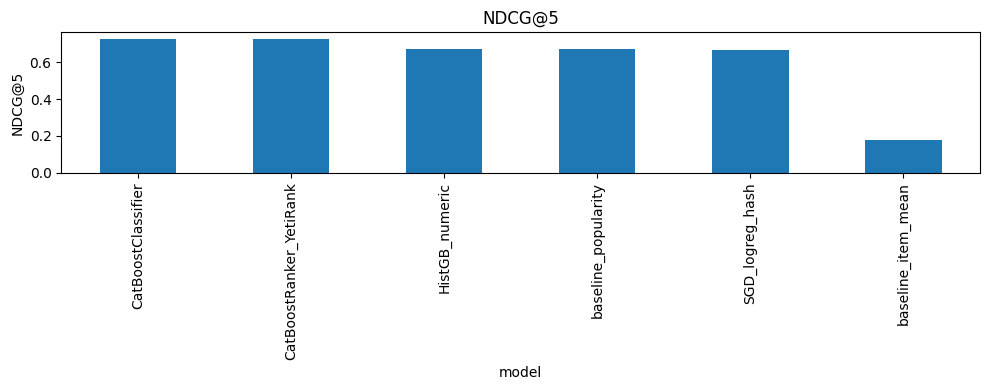

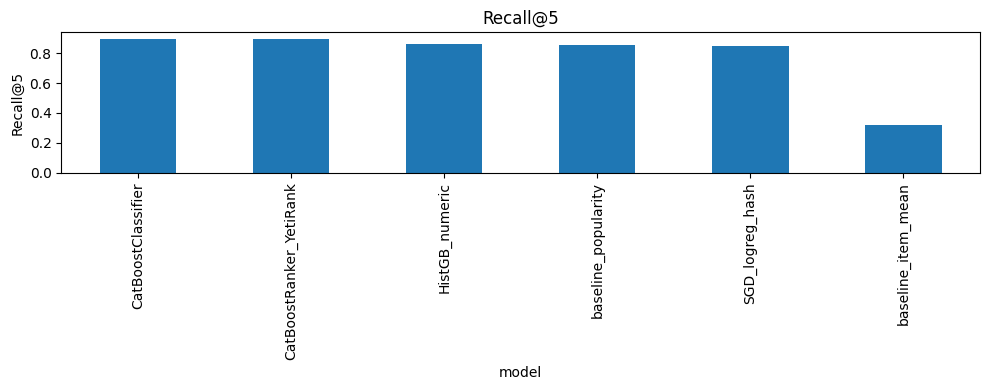

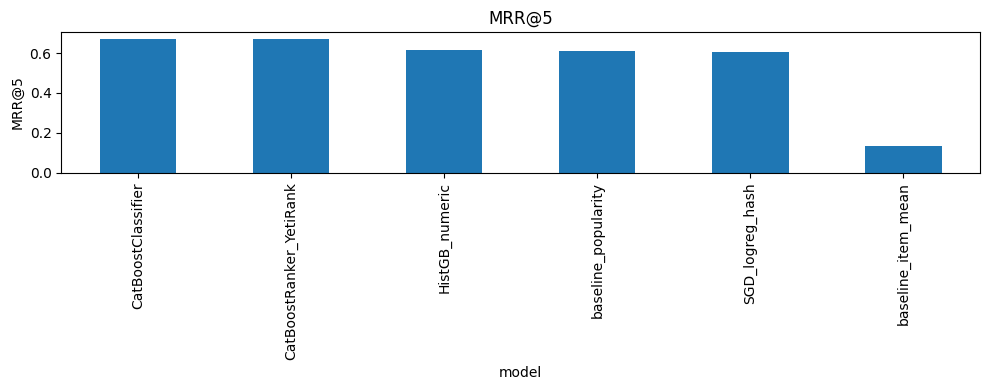

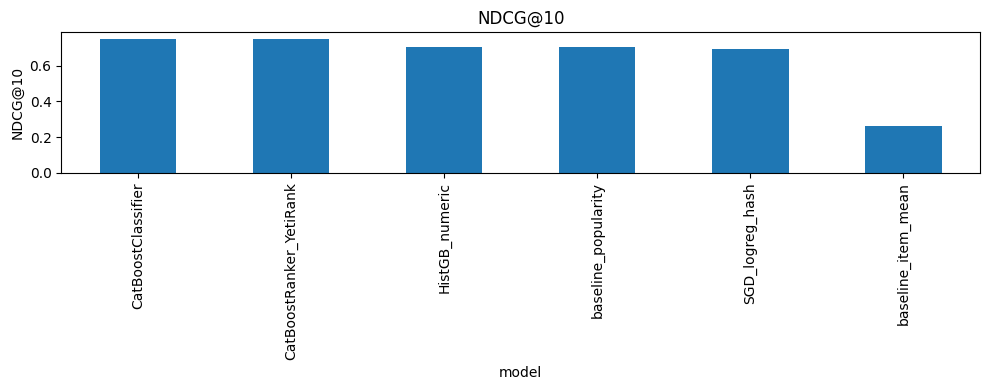

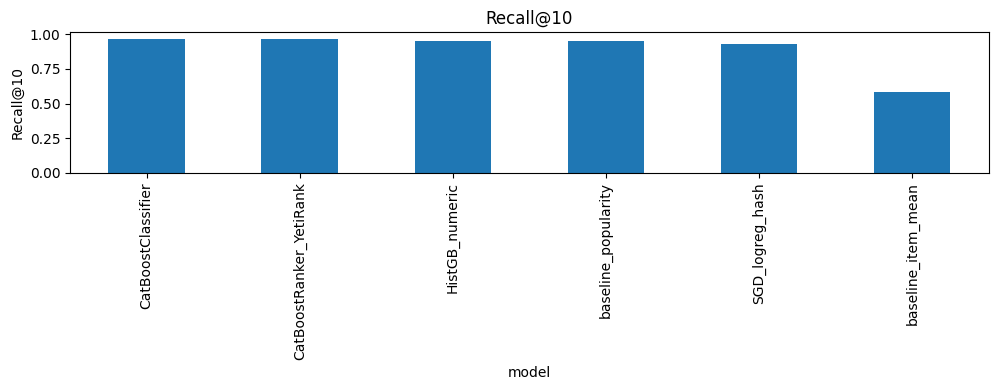

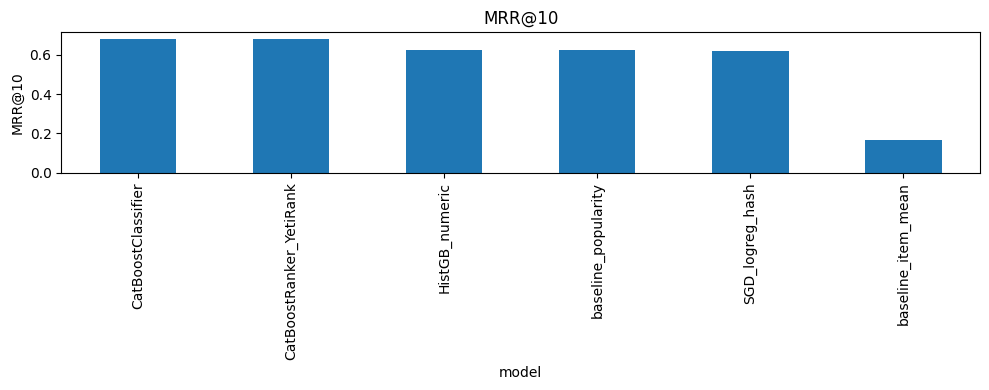

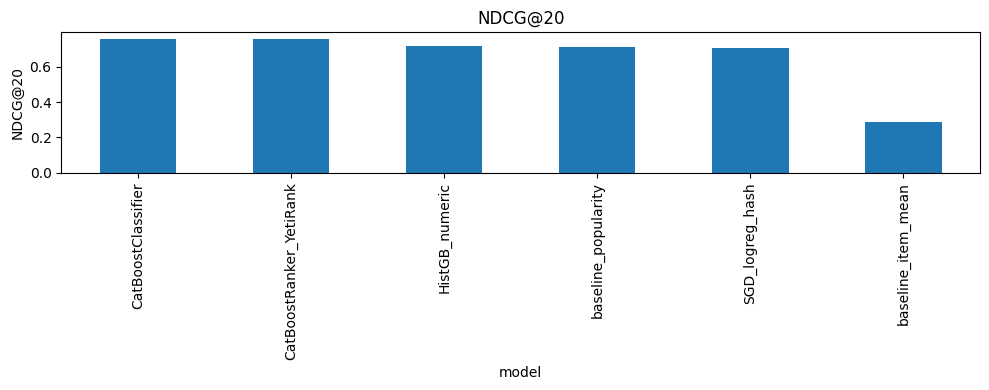

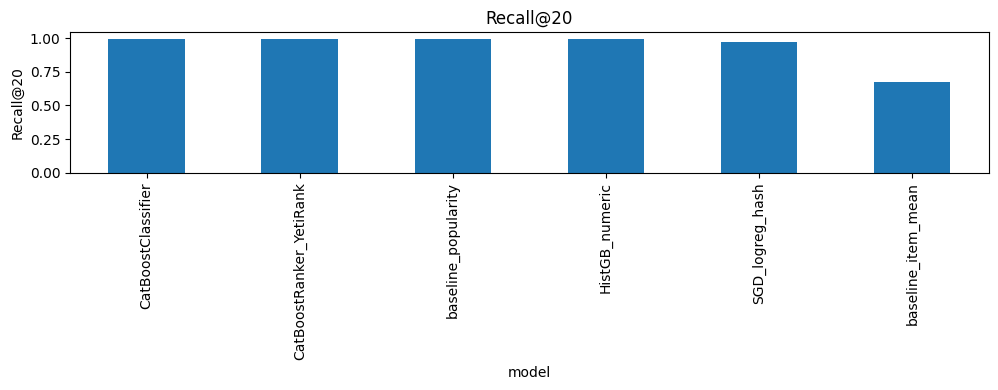

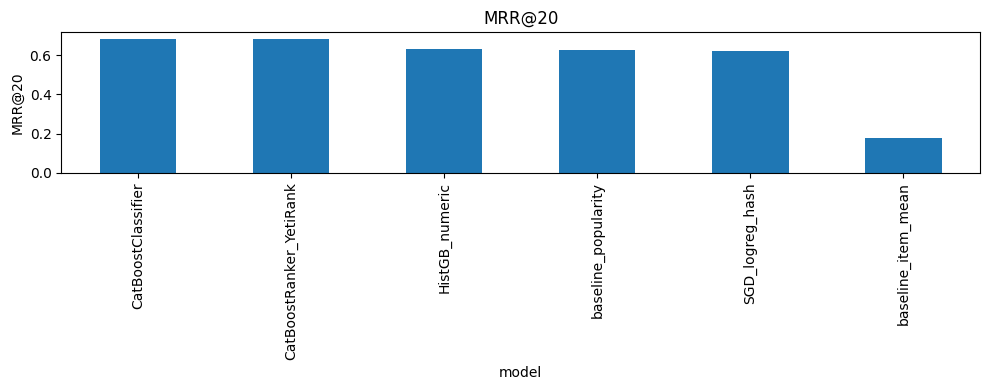

In [14]:
metrics_to_plot = []
for k in TOPK_LIST:
    metrics_to_plot += [f"NDCG@{k}", f"Recall@{k}", f"MRR@{k}"]

plot_df = results_df.set_index("model")[metrics_to_plot]

for m in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    plot_df[m].sort_values(ascending=False).plot(kind="bar")
    plt.title(m)
    plt.ylabel(m)
    plt.tight_layout()
    plt.show()


## 14. Кривая NDCG@k

Дополнительно строится кривая `NDCG@k`, которая показывает, как меняется качество ранжирования при росте длины списка рекомендаций.


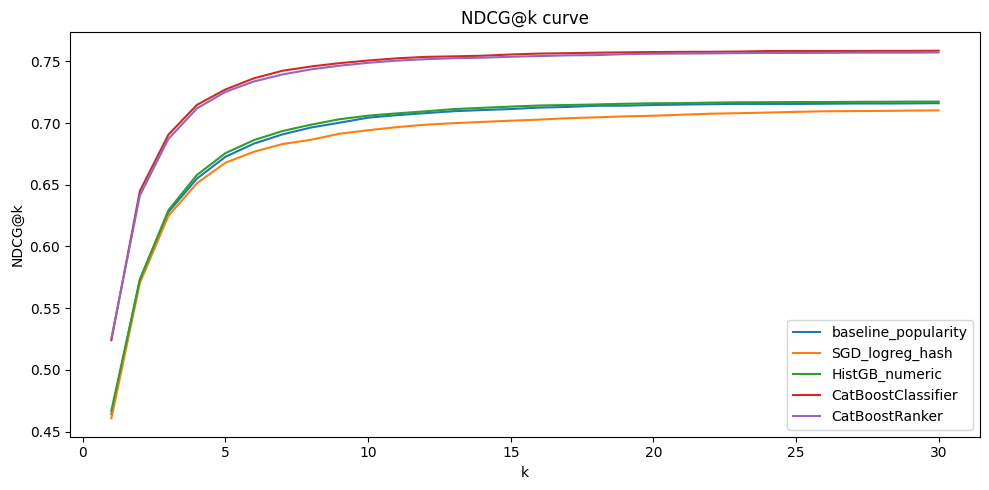

In [15]:
ks = list(range(1, 31))
def eval_curve(df_scored, ks):
    vals = []
    for k in ks:
        vals.append(eval_ranking(df_scored, k=k)[f"NDCG@{k}"])
    return np.array(vals, dtype=float)

curves = {
    "baseline_popularity": eval_curve(baseline_pop.assign(userId=test_cand["userId"]), ks),
    "SGD_logreg_hash":     eval_curve(sgd_scored, ks),
    "HistGB_numeric":      eval_curve(hgb_scored, ks),
    "CatBoostClassifier":  eval_curve(cb_scored, ks),
    "CatBoostRanker":      eval_curve(rank_scored, ks),
}

plt.figure(figsize=(10, 5))
for name, y in curves.items():
    plt.plot(ks, y, label=name)
plt.title("NDCG@k curve")
plt.xlabel("k")
plt.ylabel("NDCG@k")
plt.legend()
plt.tight_layout()
plt.show()


## 15. Финальный выбор модели

В конце ноутбука автоматически выбирается лучшая модель по `NDCG@10` и выводится итоговая таблица с лидерами.


In [16]:
target_k = 10
best_row = results_df.sort_values(f"NDCG@{target_k}", ascending=False).iloc[0]

print("Best by NDCG@{}: {}".format(target_k, best_row["model"]))
print(best_row[[f"NDCG@{target_k}", f"Recall@{target_k}", f"MRR@{target_k}", f"Precision@{target_k}"]])

print("\nTop-3 models:")
display(results_df.head(3))


Best by NDCG@10: CatBoostClassifier
NDCG@10         0.750655
Recall@10       0.966333
MRR@10          0.680694
Precision@10    0.096633
Name: 4, dtype: object

Top-3 models:


,model,Recall@5,Precision@5,NDCG@5,MRR@5,Recall@10,Precision@10,NDCG@10,MRR@10,Recall@20,Precision@20,NDCG@20,MRR@20
4,CatBoostClassifier,0.895333,0.179067,0.727221,0.670744,0.966333,0.096633,0.750655,0.680694,0.993000,0.049650,0.757525,0.682647
5,CatBoostRanker_YetiRank,0.892667,0.178533,0.725273,0.669156,0.964333,0.096433,0.748794,0.679065,0.993000,0.049650,0.756137,0.681132
3,HistGB_numeric,0.859667,0.171933,0.675608,0.614328,0.952333,0.095233,0.705967,0.627086,0.991333,0.049567,0.715997,0.629928
